In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Classification for Tabular Data
We just import the cleaned dataset from the previous notebook

In [2]:
df = pd.read_csv("./Data/diabetes_v2_cleaned.csv")

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PhysicalActivity_High,PhysicalActivity_Low,PhysicalActivity_Moderate
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,Positive,0,0,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,Negative,0,1,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,Positive,0,0,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,Negative,0,0,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,Positive,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,Negative,0,1,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,Negative,1,0,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,Negative,0,0,1
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,Positive,0,1,0


#### Train Test Split
before doing anything else, let's divide the dataset into train and test to avoid data leakage

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Separating features and target variable and converting them to NumPy arrays
y = df["Outcome"].values
X = df.drop(columns=["Outcome"]).values

In [6]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((614, 11), (614,), (154, 11), (154,))

### The scikit-learn paradigm: Transformers
Initialization → fit → transform

**Initialization**

Before calling `fit`, you create the transformer and specify its hyperparameters.

* `scaler = StandardScaler()`
* `imputer = SimpleImputer(strategy="mean")`

At this stage:
* The transformation method is chosen.
* Hyperparameters are fixed.
* No statistics have been learned yet.

**Fitting**

* `fit(X, y=None)` learns transformation parameters from training data.
  * for example: feature means and standard deviations
  * or statistics for replacing missing values

**Transformation**

* `transform(X_new)` applies the learned transformation to data.
* `fit_transform(X, y=None)` combines fitting and transforming in one step.

Key idea: initialize → fit on training data → transform both training and test data using the learned parameters.

#### Imputation
Let's remove missing values. We can do it with sklearn.

In [7]:
df.isnull().sum()

Pregnancies                    0
Glucose                        5
BloodPressure                 35
SkinThickness                227
Insulin                      374
BMI                           11
DiabetesPedigreeFunction       0
Age                            0
Outcome                        0
PhysicalActivity_High          0
PhysicalActivity_Low           0
PhysicalActivity_Moderate      0
dtype: int64

In [8]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")  # Initialization

In [9]:
imputer.fit(X_train)  # Fitting the imputer on the training data
X_train_imputed = imputer.transform(X_train)  # Transforming the training data
X_test_imputed = imputer.transform(X_test)  # Transforming the testing data using the same imputer fitted on the training data

# # or equivalently
# X_train_imputed = imputer.fit_transform(X_train)
# X_test_imputed = imputer.transform(X_test)

In [10]:
# Checking if there are still any missing values after imputation
np.isnan(X_train_imputed).sum(), np.isnan(X_test_imputed).sum()

(0, 0)

#### Label Encoder
Transformers can be used also to transform the target variable. For example, to make it numerical using a LabelEncoder

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()  # Initialization

In [13]:
y_train_encoded = le.fit_transform(y_train)  # Fitting the label encoder on the training labels and transforming them
y_test_encoded = le.transform(y_test)  # Transforming the testing labels using the same label encoder fitted on the training labels
np.unique(y_train_encoded), np.unique(y_test_encoded)

(array([0, 1]), array([0, 1]))

In [14]:
le.classes_

array(['Negative', 'Positive'], dtype=object)

## Classification

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

### Train-Val Split
Let's manually create a holdout set from the training data to use for model selection and hyperparameter tuning. We will use 20% of the training data for this purpose.

In [16]:
X_train_, X_val_, y_train_, y_val_  = train_test_split(X_train_imputed, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded)
X_train_.shape, y_train_.shape, X_val_.shape, y_val_.shape

((491, 11), (491,), (123, 11), (123,))

In [17]:
y_train_.shape

(491,)

### The scikit-learn paradigm: Classifiers and Regressors  
Initialization → fit → predict

**Initialization**

Before calling `fit`, you create the estimator and specify its hyperparameters.

* `clf = DecisionTreeClassifier(C=1.0, max_iter=1000)`

At this stage:
* The model type is chosen.
* Hyperparameters are fixed.
* No learning has happened yet.

**Fitting**

* `fit(X, y)` learns model parameters from labeled training data.
  * for a classifier: learns decision boundaries between classes
  * for a regressor: learns a function that predicts continuous values

**Prediction**

* `predict(X_new)` produces predictions using learned parameters.
* `predict_proba(X_new)` outputs class probabilities when supported.

Key idea: initialize → fit on training data → predict on new data.

#### Dummy Classifier

In [18]:
dummy = DummyClassifier()  # Initialization
dummy.fit(X_train_, y_train_)  # Fitting the dummy classifier on the training data
y_pred_dummy = dummy.predict(X_val_)  # Predicting the labels for the validation data using the dummy classifier
y_pred_dummy

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_val_, y_pred_dummy)  # Evaluating the accuracy of the dummy classifier on the validation data

# or equivalently
dummy.score(X_val_, y_val_)  # Evaluating the accuracy of the dummy classifier on the validation data using the score method

0.6504065040650406

#### Knn

In [20]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_, y_train_)
y_pred_knn = knn.predict(X_val_)
accuracy_score(y_val_, y_pred_knn)

0.7886178861788617

In [21]:
# we should probably normalize the data for KNN to work better
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # Initialization of the scaler (that is a transformer)
X_train_scaled = scaler.fit_transform(X_train_)  # Fitting the scaler on the training data and transforming it
X_val_scaled = scaler.transform(X_val_)  # Transforming the validation data using the same scaler fitted on the training data

knn = KNeighborsClassifier(n_neighbors=3)  # Initialization of the KNN classifier
knn.fit(X_train_scaled, y_train_)  # Fitting the KNN classifier on the scaled training data
knn.score(X_val_scaled, y_val_)  # Evaluating the KNN classifier on the scaled validation data

0.7642276422764228

In [22]:
# you can avoid intermediate results by using a pipeline
from sklearn.pipeline import make_pipeline

knn_pipe = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)
knn_pipe

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsclassifier', KNeighborsClassifier())])

In [23]:
knn_pipe.fit(X_train_, y_train_)  # Fitting the pipeline on the training data (the pipeline will automatically apply the transformations and then fit the classifier)
knn_pipe.score(X_val_, y_val_)  # Evaluating the pipeline on the validation

0.7723577235772358

In [24]:
# you could even impute on the fly!
from sklearn.pipeline import make_pipeline

knn_pipe = make_pipeline(
    SimpleImputer(strategy="median"),  # not needed here since we already imputed, but just to show how it would work
    StandardScaler(),
    KNeighborsClassifier()
)

knn_pipe.fit(X_train_, y_train_)
knn_pipe.score(X_val_, y_val_)

0.7723577235772358

### Exercises
- train and score a Decision Tree (init, fit, predict/score)
- train and score a Random Forest
- train and score a Gaussian Naive Bayes 
- train and score a Gaussian Naive Bayes but normalize first using a MinMaxScaler (can you do it with a pipeline?)


In [25]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

### Grid Search 

Grid search is an exhaustive hyperparameter optimization technique that systematically trains a machine learning model on all possible combinations of a pre-defined set of parameter values. By using cross-validation to evaluate each combination, it guarantees finding the best-performing model configuration within the specified search space

Let's now try to find the best hyperparameters for our Random Forest. We will use GridSearchCV for this, which will try all combinations of the specified hyperparameters and return the best one based on cross-validation performance.

In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [27]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [28]:
rf_grid = GridSearchCV(
    rf, 
    param_grid, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    n_jobs=-1, 
    refit=True
    )
rf_grid.fit(X_train, y_train_encoded)
print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation score:", rf_grid.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation score: 0.7752765560442489


In [29]:
pd.DataFrame(rf_grid.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.108182,0.010318,0.004926,0.002622,None,1,2,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.764228,0.723577,0.813008,0.723577,0.786885,0.762255,0.035152,17
1,0.215497,0.018721,0.008420,0.003593,None,1,2,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.764228,0.739837,0.804878,0.739837,0.778689,0.765494,0.024671,10
2,0.098624,0.009206,0.006207,0.003484,None,1,5,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.764228,0.731707,0.788618,0.764228,0.762295,0.762215,0.018088,18
3,0.211140,0.009565,0.006654,0.000222,None,1,5,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.780488,0.739837,0.788618,0.739837,0.778689,0.765494,0.021214,10
4,0.098045,0.020919,0.004885,0.002613,None,2,2,100,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.772358,0.731707,0.772358,0.731707,0.770492,0.755724,0.019622,24


### Exercises
#### Tune KNN with GridSearchCV

1. Build a KNeighborsClassifier():

2. Run GridSearchCV testing multiple values of k (at least 10 values).
   Try also:
   - weights: ["uniform", "distance"]
   - metric: ["euclidean", "manhattan"]

3. Print:
   - best parameters
   - best cross-validation score
   - test accuracy of the best estimator

4. (HARD) Plot the performance varying n_neighbors (using the cv_results_)

### Evaluation

In [30]:
y_true = y_test_encoded
y_pred_rf = rf_grid.predict(X_test_imputed)
y_pred_knn = knn_pipe.predict(X_test_imputed)
y_pred_dummy = dummy.predict(X_test_imputed)

In [31]:
# classification report
from sklearn.metrics import classification_report
print("Random Forest:")
print(classification_report(y_true, y_pred_rf, target_names=le.classes_))
print("KNN:")
print(classification_report(y_true, y_pred_knn, target_names=le.classes_))
print("Dummy:")
print(classification_report(y_true, y_pred_dummy, target_names=le.classes_))


Random Forest:
              precision    recall  f1-score   support

    Negative       0.77      0.86      0.81       100
    Positive       0.67      0.52      0.58        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154

KNN:
              precision    recall  f1-score   support

    Negative       0.77      0.84      0.80       100
    Positive       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154

Dummy:
              precision    recall  f1-score   support

    Negative       0.65      1.00      0.79       100
    Positive       0.00      0.00      0.00        54

    accuracy                           0.65       154
   macro avg       0.32      0.50      0.39       154
weighted avg       0.42      0.65      0.51    

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

Text(0.5, 1.0, 'Dummy Classifier')

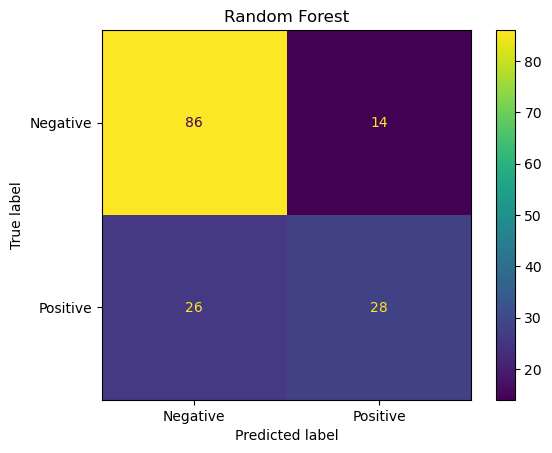

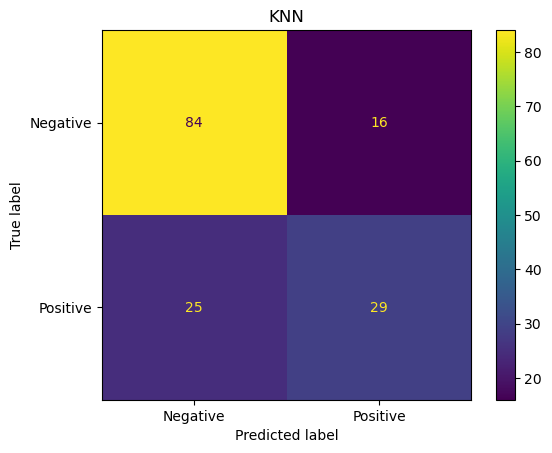

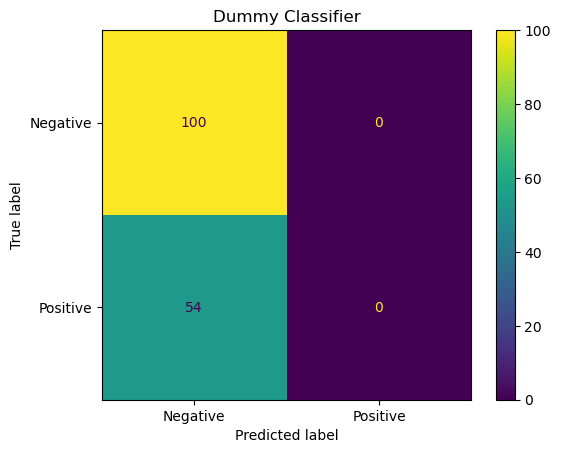

In [32]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_rf = confusion_matrix(y_true, y_pred_rf)
cm_knn = confusion_matrix(y_true, y_pred_knn)
cm_dummy = confusion_matrix(y_true, y_pred_dummy)


ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_).plot()
plt.gca().set_title("Random Forest")
ConfusionMatrixDisplay(cm_knn, display_labels=le.classes_).plot()
plt.gca().set_title("KNN")
ConfusionMatrixDisplay(cm_dummy, display_labels=le.classes_).plot()
plt.gca().set_title("Dummy Classifier")

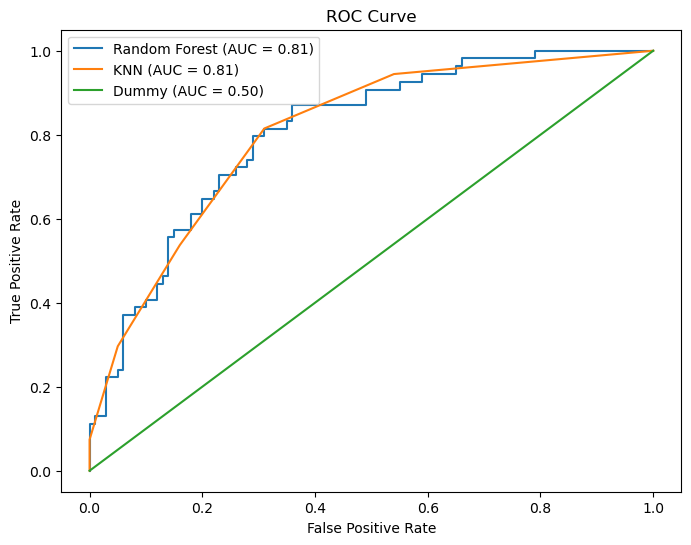

In [33]:
# Roc curve
from sklearn.metrics import roc_curve, auc
y_score_rf = rf_grid.predict_proba(X_test_imputed)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_true, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

y_score_knn = knn_pipe.predict_proba(X_test_imputed)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_true, y_score_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

y_score_dummy = dummy.predict_proba(X_test_imputed)[:, 1]
fpr_dummy, tpr_dummy, _ = roc_curve(y_true, y_score_dummy)
roc_auc_dummy = auc(fpr_dummy, tpr_dummy)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_knn:.2f})")
plt.plot(fpr_dummy, tpr_dummy, label=f"Dummy (AUC = {roc_auc_dummy:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Exercises


#### Data Leaking
Which of the following is correct given X and y full dataset with labels? 

```python
# option A
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
```

```python
# option B
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
```


#### Plot the Roc Curves for each approach we tested until now!